# Semi-Classical Signal Analysis (SCSA) — Tutorial

This notebook is a self-contained tutorial for replicating the results from:

> Laleg-Kirati, T.-M., Crépeau, E., & Sorine, M. (2013). **Semi-classical signal analysis**. *Mathematics of Control, Signals, and Systems*, 25(1), 37–61. https://doi.org/10.1007/s00498-012-0091-1

---

## What is SCSA?

The **Semi-Classical Signal Analysis (SCSA)** method decomposes a positive signal $y(t)$ by treating it as a potential of a **1D Schrödinger operator** (Eq. 1 of the paper):

$$H_h(y)\psi(t) = -h^2 \frac{d^2\psi(t)}{dt^2} - y(t)\psi(t), \quad \psi \in H^2(\mathbb{R}), \quad h > 0$$

The signal $y$ must satisfy $y \in \mathcal{B}$, the Faddeev class of non-negative integrable functions (Eq. 2). Under this condition, $H_h(y)$ has a **finite number $N_h$ of negative eigenvalues**, denoted $-\kappa_{nh}^2$ with $\kappa_{nh} > 0$ and $\kappa_{1h} > \kappa_{2h} > \cdots > \kappa_{N_h h}$.

The signal is then reconstructed from the discrete spectrum using **Eq. (3) of the paper**:

$$y_h(t) = 4h \sum_{n=1}^{N_h} \kappa_{nh} \, \psi_{nh}^2(t), \quad t \in \mathbb{R}$$

where $\psi_{nh}$ are the $L^2$-normalized eigenfunctions associated with $-\kappa_{nh}^2$.

As $h \to 0$, the number of eigenvalues grows and the reconstruction improves: $y_h \to y$.

$$N_h \sim 1/(\pi h)\int\sqrt{y}\,dt$$
---

## Tutorial Goal

We reproduce **Section 4.2** of the paper: analysis of the **sech-squared (Pöschl–Teller) function**

$$y(t) = \operatorname{sech}^2(t - t_0)$$

This case admits **exact analytical eigenvalues**, providing a ground truth for numerical validation.

**Key results replicated in this notebook:**
1. Signal reconstruction for $N_\chi = 1, 2, 3, 4$ negative eigenvalues (Figure 5 of the paper)
2. Eigenvalue behavior as $\chi = 1/h^2$ increases (Figure 3b)
3. Reconstruction error (MSE) and $N_\chi$ as functions of $\chi$ (Figure 3a)

In [1]:
from pyscsa import SCSA1D
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## 1. Define the Signal

The sech-squared function: $y(t) = \text{sech}^2(t - t_0)$


In [2]:
def sech_squared(t, t0=6.0):
    """Sech-squared function"""
    return 1.0 / np.cosh(t - t0)**2

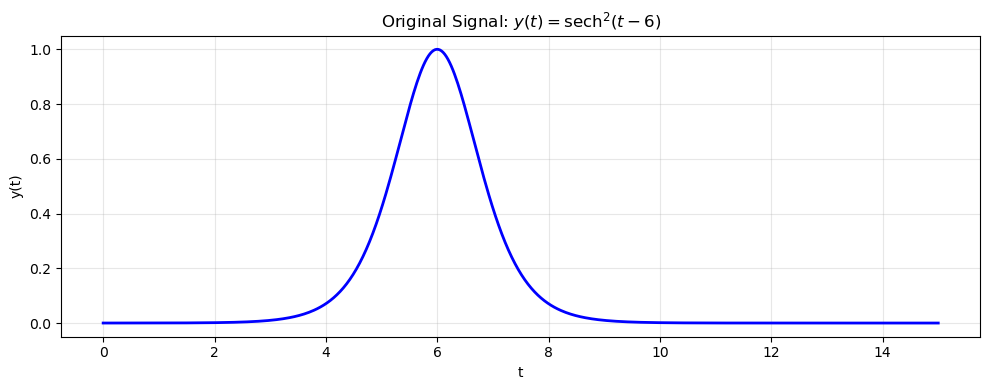

In [3]:
# Create the signal on the interval [0, 15]
M = 512  # Number of grid points
t_grid = np.linspace(0, 15, M)
t0 = 6.0
y_signal = sech_squared(t_grid, t0)

# Plot the original signal
plt.figure(figsize=(10, 4))
plt.plot(t_grid, y_signal, 'b-', linewidth=2)
plt.xlabel('t')
plt.ylabel('y(t)')
plt.title(r'Original Signal: $y(t) = \mathrm{sech}^2(t - 6)$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. SCSA Reconstruction

### Notation: $\chi$ vs $h$

Throughout Section 4 of the paper, the authors adopt the substitution $\chi = 1/h^2$ to simplify notation. The associated quantities are (paper, p. 44):

$$\chi = \frac{1}{h^2}, \quad N_h = N_\chi, \quad \kappa_{n\chi}^2 = \frac{\kappa_{nh}^2}{h^2}$$

The reconstruction formula **Eq. (31)** then becomes:

$$y_\chi(t) = \frac{4}{\chi} \sum_{n=1}^{N_\chi} \kappa_{n\chi} \, \psi_{n\chi}^2(t)$$

where $-\kappa_{n\chi}^2$ are the negative eigenvalues of $H_1(\chi y) = -d^2/dt^2 - \chi y(t)$ and $\psi_{n\chi}$ are the $L^2$-normalized eigenfunctions.

### The Pöschl–Teller Potential

For $y(t) = \operatorname{sech}^2(t - t_0)$, the Schrödinger potential is $-\chi\operatorname{sech}^2(t-t_0)$, known in quantum mechanics as the **Pöschl–Teller potential** (paper, §4.2).

A key result: the Pöschl–Teller potential is **reflectionless** (Proposition 4 of the paper) when:

$$\chi = \chi_p = N(N+1), \quad N = 1, 2, 3, \ldots \quad \text{(Eq. 39)}$$

At these special values, the SCSA yields an **exact** reconstruction ($y_\chi = y$), and the eigenvalues are known analytically from quantum mechanics:

| $\chi_p = N(N+1)$ | $N_\chi$ | Eigenvalues $-\kappa_{n\chi}^2$ |
|-------------------|----------|---------------------------------|
| $\chi=2$ ($N=1$)  | 1 | $\lambda_1 = -1$ |
| $\chi=6$ ($N=2$)  | 2 | $\lambda_1 = -4,\; \lambda_2 = -1$ |
| $\chi=12$ ($N=3$) | 3 | $\lambda_1 = -9,\; \lambda_2 = -4,\; \lambda_3 = -1$ |
| $\chi=20$ ($N=4$) | 4 | $\lambda_1 = -16,\; \lambda_2 = -9,\; \lambda_3 = -4,\; \lambda_4 = -1$ |

In general, at $\chi_p = N(N+1)$: $\kappa_{n\chi} = N + 1 - n$ for $n = 1, \ldots, N$.

> **Validation:** compare the printed eigenvalues in the cells below against these exact values.

### Norm Computation Methods

Before reconstructing, the eigenfunctions $\psi_{n\chi}$ must be $L^2$-normalized. Three numerical integration methods are compared to verify consistency:

- **Trapezoidal**: Composite trapezoidal quadrature
- **Scipy**: Simpson's rule via `scipy.integrate.simpson`
- **Custom**: Custom implementation of Simpson's rule

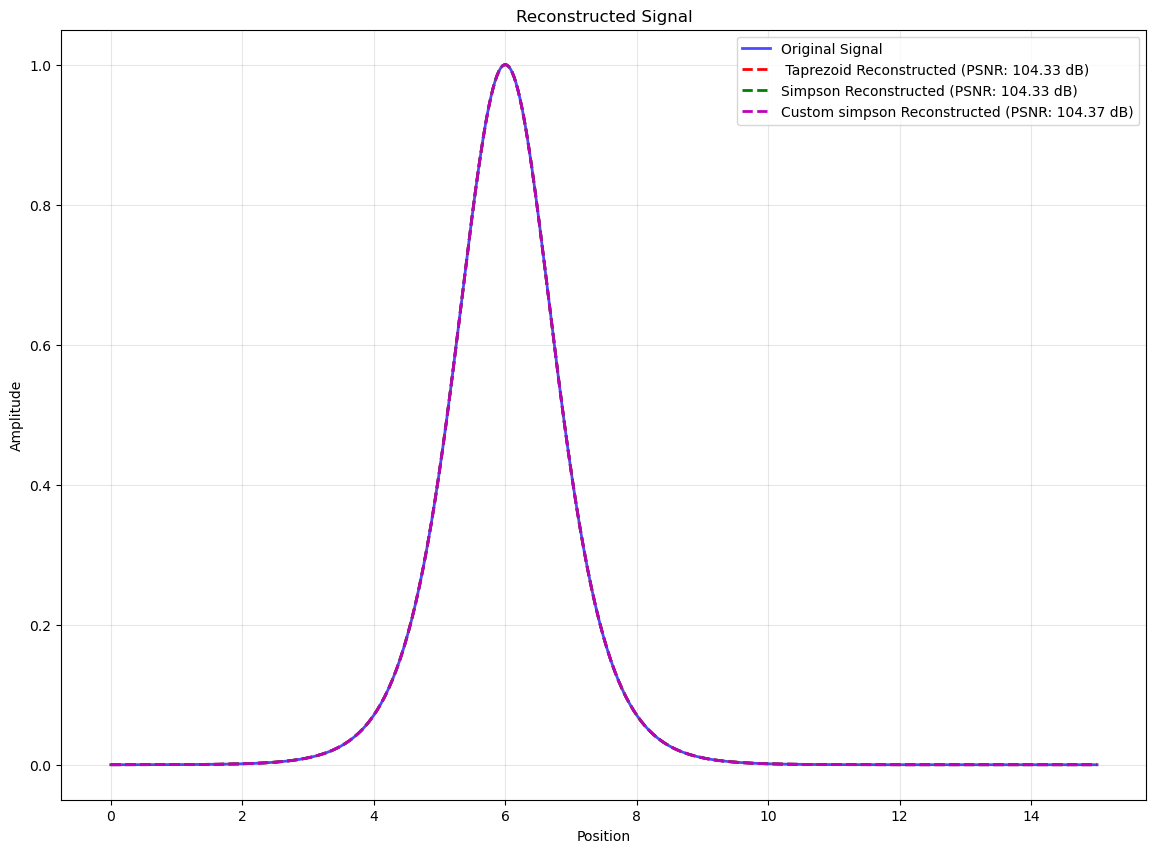

In [4]:
# reconstruct using SCSA
scsa = SCSA1D(fe=t_grid[1] - t_grid[0], gmma=0.5)
result_trap = scsa.reconstruct(h=0.7071,  signal=y_signal, method_norm='trapezoidal')
result_scipy = scsa.reconstruct(h=0.7071,  signal=y_signal, method_norm='scipy')
result_custom = scsa.reconstruct(h=0.7071,  signal=y_signal, method_norm='custom')

x= np.linspace(0, 15, M)

fig, axes = plt.subplots(1, 1, figsize=(14, 10))

# Plot 1: Clean signal comparison
plt.plot(x, y_signal, 'b-', linewidth=2, label='Original Signal', alpha=0.7)
plt.plot(x, result_trap.reconstructed, 'r--', linewidth=2, label=f' Taprezoid Reconstructed (PSNR: {result_trap.metrics["psnr"]:.2f} dB)')
plt.plot(x, result_scipy.reconstructed, 'g--', linewidth=2, label=f'Simpson Reconstructed (PSNR: {result_scipy.metrics["psnr"]:.2f} dB)')
plt.plot(x, result_custom.reconstructed, 'm--', linewidth=2, label=f'Custom simpson Reconstructed (PSNR: {result_custom.metrics["psnr"]:.2f} dB)')
plt.title('Reconstructed Signal')
plt.xlabel('Position')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)

## 3. Effect of the Semi-Classical Parameter $h$ (or $\chi = 1/h^2$)

The parameter $h$ controls how many **bound states** (negative eigenvalues) the Schrödinger operator admits, and therefore how many spectral components are used in the reconstruction.

### Reflectionless Values $\chi_p = N(N+1)$

For the sech-squared potential, the reconstruction is **exact** ($y_\chi = y$) precisely at $\chi_p = N(N+1)$ (Eq. 39, Proposition 4). These are the values tested below, chosen so that $N_\chi = 1, 2, 3, 4$:

| $h$ | $\chi = 1/h^2$ | $N_\chi$ | Exact (reflectionless?) |
|-----|----------------|----------|------------------------|
| $1/\sqrt{2} \approx 0.7071$ | $2 = 1\times 2$ | 1 | Yes ($\chi_1 = 2$) |
| $1/\sqrt{6} \approx 0.4082$ | $6 = 2\times 3$ | 2 | Yes ($\chi_2 = 6$) |
| $1/\sqrt{12} \approx 0.2887$ | $12 = 3\times 4$ | 3 | Yes ($\chi_3 = 12$) |
| $1/\sqrt{20} \approx 0.2236$ | $20 = 4\times 5$ | 4 | Yes ($\chi_4 = 20$) |

At reflectionless values, the reconstruction is exact by **Proposition 4** of the paper (equivalently, by the Deift–Trubowitz formula — the continuous spectrum contributes zero).

### Interpreting the Printed Eigenvalues

Each cell prints `result.eigenvalues / h**2`, which gives the eigenvalues $\lambda_n$ of $H_1(\chi y) = -d^2/dt^2 - \chi y$. Compare against the exact values in the table above. The **largest** $\kappa_{n\chi}$ (most negative $\lambda_n$) corresponds to the fastest component; the smallest $\kappa_{n\chi}$ to the slowest. In the context of arterial blood pressure, the largest corresponds to the **systolic phase** and the smallest to the **diastolic phase** (Section 5 of the paper).


SIGNAL RECONSTRUCTION WITH DIFFERENT h VALUES

h = 0.707:
  χ = 1/h² = 2.00
  N_h = 1 negative eigenvalues
eigenvalues = [-1.00002795]
  MSE = 0.00000000

h = 0.408:
  χ = 1/h² = 6.00
  N_h = 2 negative eigenvalues
eigenvalues = [-4.         -0.99999287]
  MSE = 0.00000000

h = 0.289:
  χ = 1/h² = 12.00
  N_h = 3 negative eigenvalues
eigenvalues = [-9.         -4.         -1.00001425]
  MSE = 0.00000000

h = 0.224:
  χ = 1/h² = 20.00
  N_h = 4 negative eigenvalues
eigenvalues = [-16.          -9.          -4.          -0.99997622]
  MSE = 0.00000000



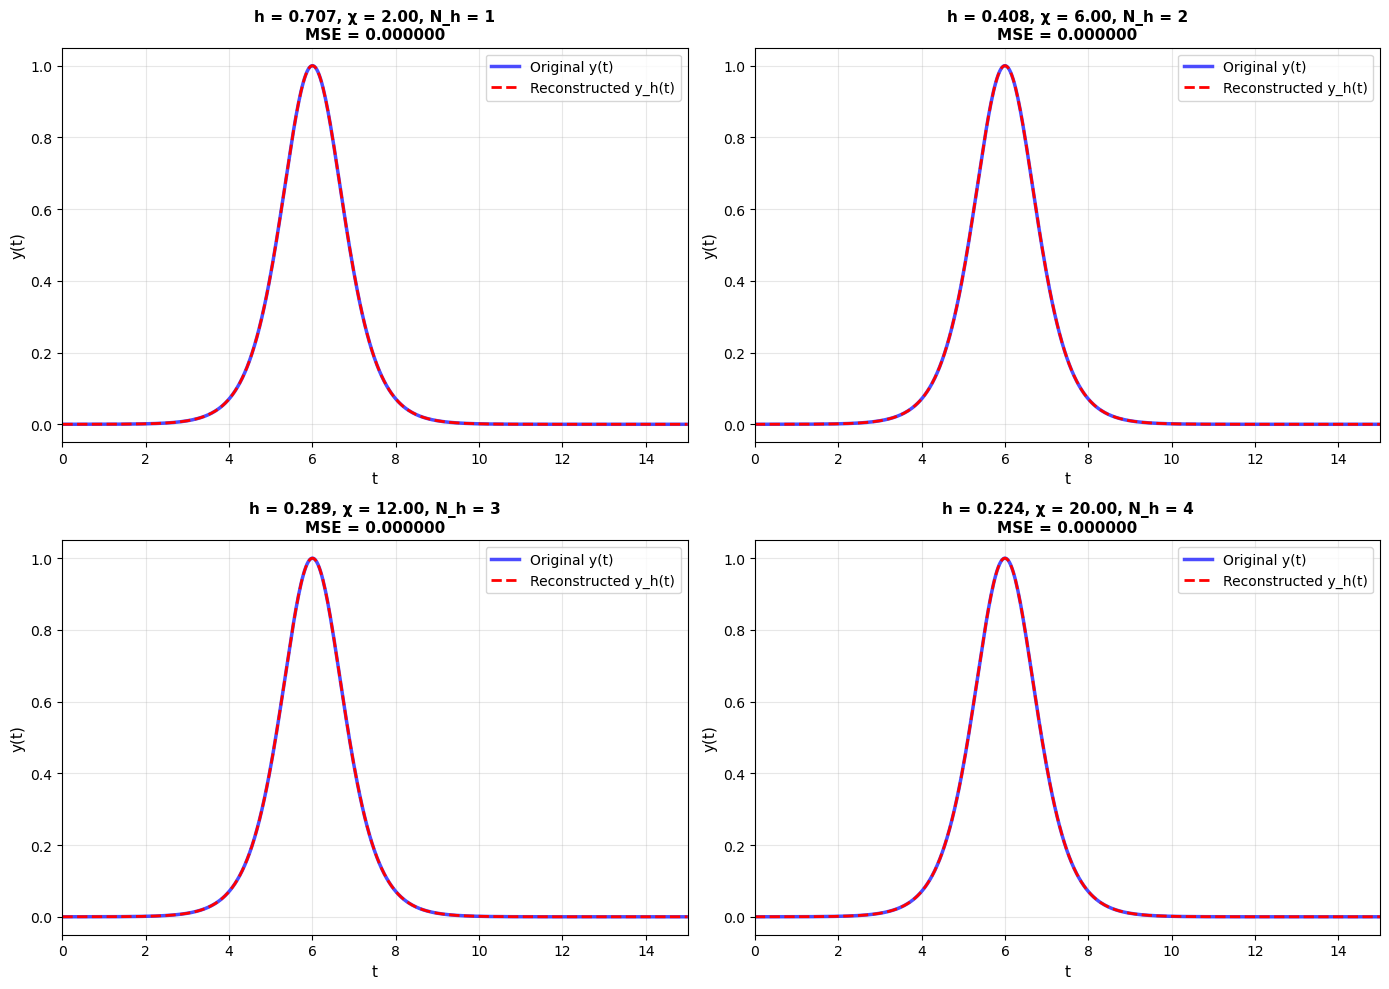

In [5]:
# Demonstration: Signal reconstruction for specific h values
print("\n" + "="*80)
print("SIGNAL RECONSTRUCTION WITH DIFFERENT h VALUES")
print("="*80 + "\n")

h_demo = [0.7071, 0.408248290463863, 0.28867513459481287, 0.22360679774997896]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, h in enumerate(h_demo):
    chi = 1.0 / h**2
    lambda_g=0.
    gama = 0.5
    scsa = SCSA1D(fe=t_grid[1] - t_grid[0], gmma=gama)
    result = scsa.reconstruct(h=h,  signal=y_signal,lambda_g=lambda_g)
    y_recon = result.reconstructed
    N_h = result.num_eigenvalues
    mse = np.mean((y_signal - y_recon)**2)
    
    axes[idx].plot(t_grid, y_signal, 'b-', linewidth=2.5, label='Original y(t)', alpha=0.7)
    axes[idx].plot(t_grid, y_recon, 'r--', linewidth=2, label='Reconstructed y_h(t)')
    axes[idx].set_xlabel('t', fontsize=11)
    axes[idx].set_ylabel('y(t)', fontsize=11)
    axes[idx].set_title(f'h = {h:.3f}, χ = {chi:.2f}, N_h = {N_h}\nMSE = {mse:.6f}', 
                       fontsize=11, fontweight='bold')
    axes[idx].legend(fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim([0, 15])
    axes[idx].set_ylim([-0.05, 1.05])
    
    print(f"h = {h:.3f}:")
    print(f"  χ = 1/h² = {chi:.2f}")
    print(f"  N_h = {N_h} negative eigenvalues")
    print(f'eigenvalues = {(np.sort(result.eigenvalues[:N_h])/h**2)}')
    print(f"  MSE = {mse:.8f}\n")

plt.tight_layout()
plt.savefig('reconstruction_vs_h.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Eigenvalue and Error Analysis vs $\chi = 1/h^2$

We now sweep $\chi$ over $[1, 30]$ and track three quantities, reproducing **Figure 3 of the paper**.

### What Each Plot Shows

**Top-left — First four eigenvalues vs $\chi$ (Figure 3b of the paper):**
The eigenvalues of $(-D_2 - \chi\,\mathrm{diag}(Y))$ are initially positive and **decrease** as $\chi$ grows. At each transition $N_\chi \to N_\chi + 1$, a positive eigenvalue crosses zero and becomes negative (a new bound state is born). The first four negative eigenvalues $-\kappa_{n\chi}^2$ become increasingly negative as $\chi$ grows.

**Top-right — Number of negative eigenvalues $N_\chi$ vs $\chi$ (Figure 3a, top, of the paper):**
$N_\chi$ is a **non-decreasing step function** of $\chi$ (Proposition 1 of the paper). For the sech-squared potential, the steps occur at $\chi_p = N(N+1) = 2, 6, 12, 20, \ldots$

**Bottom-left — MSE vs $\chi$ (Figure 3a, bottom, of the paper):**
The mean square error $J(\chi) = \frac{1}{M}\sum_i(y_i - y_{\chi i})^2$ (Eq. 37 of the paper). The paper notes:
- MSE has **local minima** at the reflectionless values $\chi_p = N(N+1)$ where $-\chi y$ is a reflectionless potential and reconstruction is exact
- There exist local maxima just after each step of $N_\chi$ (the new bound state has not yet converged to its final shape)
- For all $\epsilon > 0$, there exists $\chi_\epsilon$ such that $J(\chi) < \epsilon$ for all $\chi > \chi_\epsilon$

**Bottom-right — $\chi$ vs $h$ relationship:**
The identity $\chi = 1/h^2$ shown for reference.

> These plots reproduce **Figure 3** of Laleg-Kirati et al. (2013), Section 4.2.


EIGENVALUE ANALYSIS VS h


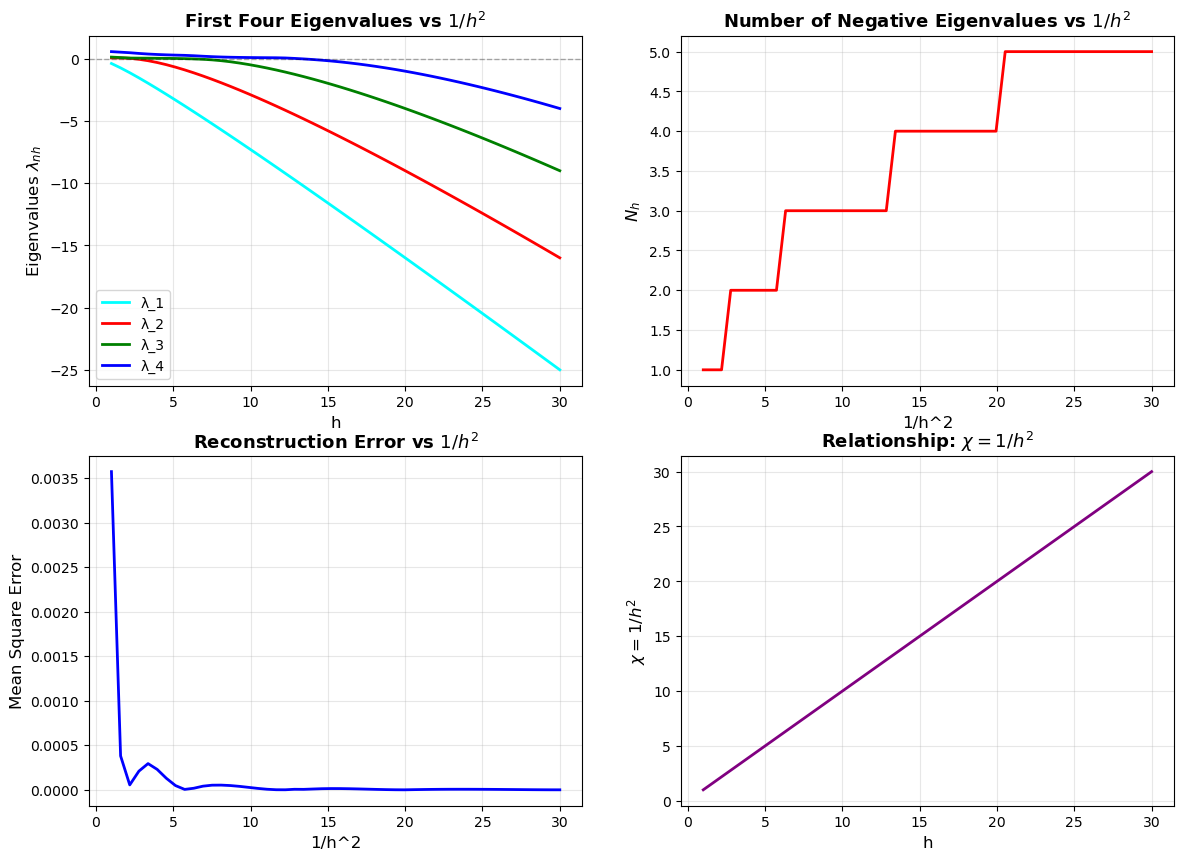

In [6]:
# Plot: Eigenvalues as function of h
print("\n" + "="*80)
print("EIGENVALUE ANALYSIS VS h")
print("="*80)

chi = np.linspace(1, 30,50)  # χ values from 1 to 30
h_range = 1.0 / np.sqrt(chi)  # Corresponding h values
eigenvalue_histories_h = [[], [], [], []]  # First 4 eigenvalues
N_h_values = []
mse_h_values = []
#eig_hist = np.zeros((4, len(chi)))
eig_hist= [[], [], [], []]  # First 4 eigenvalues

for i, h in enumerate(h_range):
    lambda_g=0.
    gama = 0.5
    scsa = SCSA1D(fe=t_grid[1] - t_grid[0], gmma=gama)
    result = scsa.reconstruct(h=h,  signal=y_signal,lambda_g=lambda_g)
    y_recon = result.reconstructed

    # Eigenvalues — flatten to guarantee 1D scalar array
    eigs = np.sort(result.eigenvalues/h**2).flatten()

    if len(eigs) < 4:
       eig_hist[:result.num_eigenvalues, i] = eigs[:len(eigs)]


    for i in range(4):
        if i < len(eigs):
            eig_hist[i].append(eigs[i])
        else:
            eig_hist[i].append(np.nan)
        
    
    # Number of negative eigenvalues
    N_h_values.append(result.num_eigenvalues)

    # MSE
    if result.num_eigenvalues > 0:
        mse = np.mean((y_signal - y_recon)**2)
    else:
        mse = np.mean(y_signal**2)
    mse_h_values.append(mse)



# Create figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Eigenvalues vs h
ax = axes[0, 0]
colors = ['cyan', 'red', 'green', 'blue']
for i in range(4):
    ax.plot(chi, eig_hist[i], 
             color=colors[i], linewidth=2, label=f'λ_{i+1}')
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3, linewidth=1)
ax.set_xlabel('h', fontsize=12)
ax.set_ylabel('Eigenvalues $\\lambda_{nh}$', fontsize=12)
ax.set_title('First Four Eigenvalues vs $1/h^2$', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Number of negative eigenvalues vs h
ax = axes[0, 1]
ax.plot(chi, N_h_values, 'r-', linewidth=2)
ax.set_xlabel('1/h^2', fontsize=12)
ax.set_ylabel('$N_h$', fontsize=12)
ax.set_title('Number of Negative Eigenvalues vs $1/h^2$', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Plot 3: MSE vs h
ax = axes[1, 0]
ax.plot(chi, mse_h_values, 'b-', linewidth=2)
ax.set_xlabel('1/h^2', fontsize=12)
ax.set_ylabel('Mean Square Error', fontsize=12)
ax.set_title('Reconstruction Error vs $1/h^2$', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Plot 4: h vs χ relationship
ax = axes[1, 1]
chi_from_h = 1.0 / h_range**2
ax.plot(chi, chi_from_h, 'purple', linewidth=2)
ax.set_xlabel('h', fontsize=12)
ax.set_ylabel('$\\chi = 1/h^2$', fontsize=12)
ax.set_title('Relationship: $\\chi = 1/h^2$', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)



## Summary

This tutorial reproduced the main numerical results of **Section 4.2** of Laleg-Kirati et al. (2013) for $y(t) = \operatorname{sech}^2(t - 6)$ on $[0, 15]$ with $M = 512$ grid points.



### Reference

Laleg-Kirati, T.-M., Crépeau, E., & Sorine, M. (2013). Semi-classical signal analysis. *Mathematics of Control, Signals, and Systems*, **25**(1), 37–61.

